<a href="https://colab.research.google.com/github/Sacamcri679/CourseraDMMachineLearning/blob/main/Lab1Titanic0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# == 0. Imports & setup ==
# (You may add more imports as needed, but keep these.)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
sns.set_theme()

# Autograder will look for: df, make_features, preprocess_pipe, X_ready

In [3]:
# TODO: Load dataset into df
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

# TODO: Head, shape, dtypes, missing counts, describe
display(df.head())
print("\Shape:", df.shape)
print("\nData Types: \n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())
display(df.describe())
display(df.describe(include='object'))

<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_463/3150036894.py:9: SyntaxWarning: invalid escape sequence '\S'
  print("\Shape:", df.shape)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


\Shape: (891, 15)

Data Types: 
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing Values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


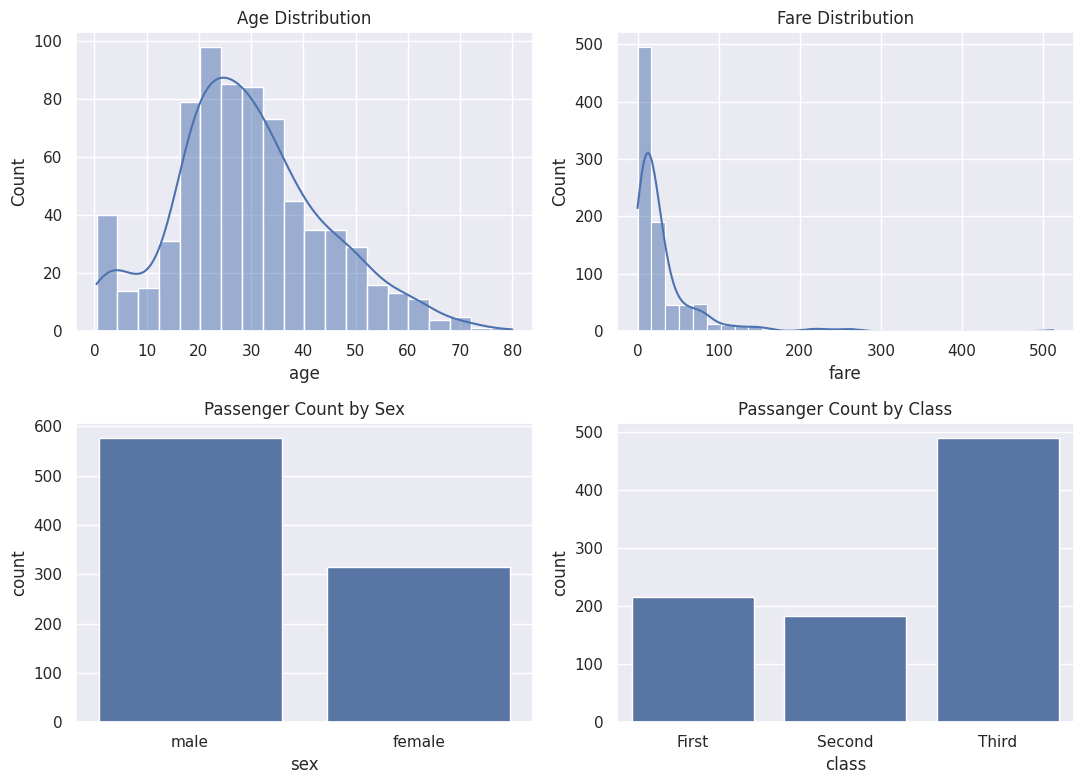

In [4]:
# TODO: Create distribution plots
fig, axes = plt.subplots(2, 2, figsize=(11,8))

sns.histplot(data=df, x='age', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(data=df, x='fare', kde=True, ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Fare Distribution')

sns.countplot(data=df, x='sex', ax=axes[1, 0])
axes[1, 0].set_title('Passenger Count by Sex')

sns.countplot(data=df, x='class', ax=axes[1, 1])
axes[1, 1].set_title('Passanger Count by Class')

plt.tight_layout()
plt.show()

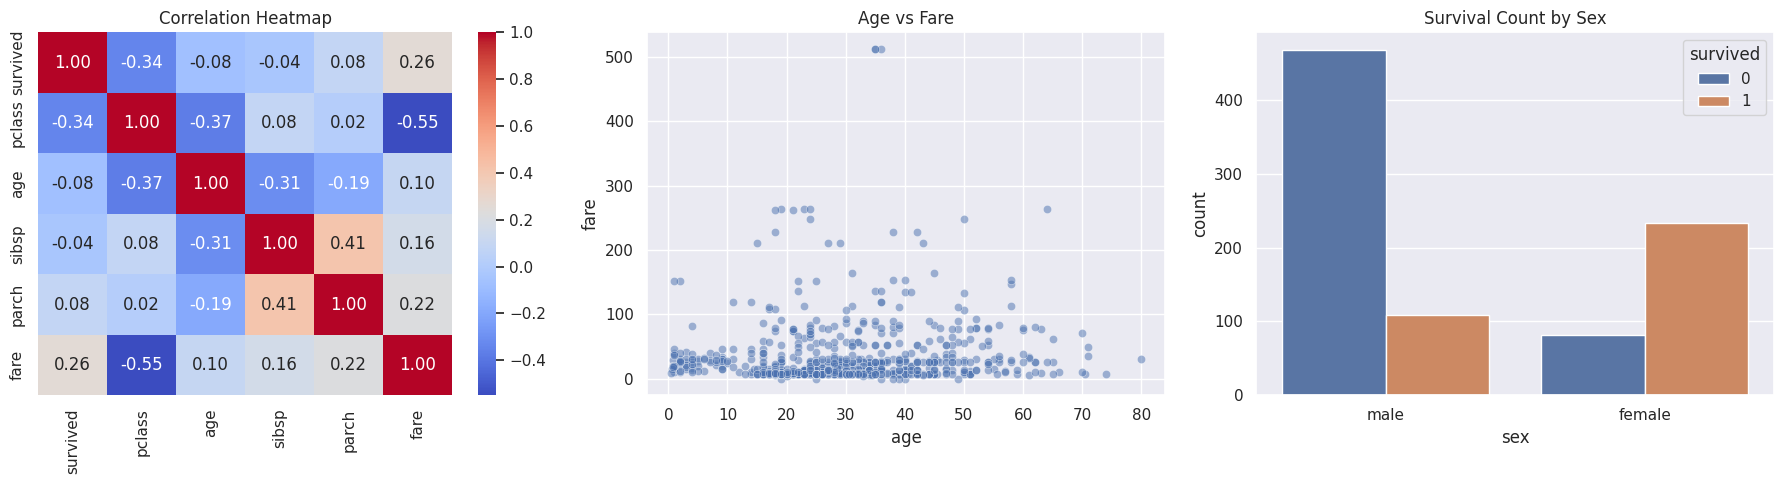

In [5]:
# TODO: Correlation heatmap and two relationship plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

num_cols = df.select_dtypes(include=['number'])
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Correlation Heatmap')

sns.scatterplot(data=df, x='age', y='fare', alpha=0.5, ax=axes[1])
axes[1].set_title('Age vs Fare')

sns.countplot(data=df, x='sex', hue='survived', ax=axes[2])
axes[2].set_title('Survival Count by Sex')

plt.tight_layout()
plt.show()


In [6]:
# TODO: Drop sparse column and show remaining missingness
if "deck" in df.columns:
    df = df.drop(columns=["deck"])
print("Remaining Missing Values:\n", df.isna().sum())

Remaining Missing Values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64


In [7]:
# TODO: Implement and apply make_features
def make_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    # family_size
    df_out['family_size'] = df_out['sibsp'] + df_out['parch'] + 1

    # is_alone
    df_out['is_alone'] = (df_out['family_size'] == 1).astype(int)

    # fare_per_person (handle divide by zero)
    df_out['fare_per_person'] = df_out['fare'] / df_out['family_size']
    return df_out

df = make_features(df)
display(df[["sibsp","parch","family_size","is_alone","fare","fare_per_person"]].head())

,sibsp,parch,family_size,is_alone,fare,fare_per_person
0,1,0,2,0,7.2500,3.62500
1,1,0,2,0,71.2833,35.64165
2,0,0,1,1,7.9250,7.92500
3,1,0,2,0,53.1000,26.55000
4,0,0,1,1,8.0500,8.05000


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# TODO: Separate features/target (exclude 'alive')
TARGET = "survived"
X = df.drop(columns=[TARGET, "alive"])
y = df[TARGET]

# TODO: Identify numeric & categorical feature lists
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

# TODO: Define numeric and categorical pipelines
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

# TODO: Build ColumnTransformer as preprocess_pipe
preprocess_pipe = ColumnTransformer([('num', numeric_pipe, numeric_features), ('cat', categorical_pipe, categorical_features)])

# TODO: Fit & transform
X_ready = preprocess_pipe.fit_transform(X)
print("X_ready shape: ", X_ready.shape)
try:
    print("\nFeature names preview:")
    print(preprocess_pipe.get_feature_names_out()[:10])
except Exception as e:
    print("Feature names not available:", e)

X_ready shape:  (891, 26)

Feature names preview:
['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'num__family_size' 'num__is_alone' 'num__fare_per_person'
 'cat__sex_female' 'cat__sex_male']
